In [9]:
import numpy as np 
import matplotlib.pyplot as plt 
import tensorflow as tf 
from scipy.optimize import minimize
import warnings
import pandas as pd
import os
warnings.filterwarnings("ignore")
SEED=42
np.random.seed(SEED)
tf.random.set_seed(SEED)

CONFIG={
    "n_samples": 500,
    "noise_level":0.02,
    "seed": SEED,
}

TRUE_FORMULAS={
    "qho":       "E = omega * (n + 1/2)",
    "hydrogen":  "E = -1 / n^2",
    "debroglie": "lambda = 1 / p",
}

print("Tensorflow: ", tf.__version__)
print("Numpy: ", np.__version__)
print("Seeds set. config loaded.")

Tensorflow:  2.21.0
Numpy:  2.4.6
Seeds set. config loaded.


In [8]:
def generate_qho(n_samples=500, noise_level=0.02, seed=42):
    """Quantum harmonic oscillator: E = omega * (n + 1/2). Features: [n, omega]."""
    rng = np.random.default_rng(seed)
    n = rng.integers(0, 11, size=n_samples).astype(np.float32)
    omega = rng.uniform(0.5, 3.0, size=n_samples).astype(np.float32)
    E_clean = omega * (n + 0.5)
    noise = rng.normal(0, noise_level * np.abs(E_clean)).astype(np.float32)
    E = E_clean + noise
    X = np.stack([n, omega], axis=1)
    return X, E

def generate_hydrogen(n_samples=500, noise_level=0.02, seed=42):
    """Hydrogen energy levels: E = -1/n^2. Features: [n]. Units: Rydberg."""
    rng = np.random.default_rng(seed + 1)   # offset seed per dataset
    n = rng.integers(1, 16, size=n_samples).astype(np.float32)
    E_clean = -1.0 / (n ** 2)
    noise = rng.normal(0, noise_level * np.abs(E_clean)).astype(np.float32)
    E = E_clean + noise
    X = n.reshape(-1, 1)
    return X, E

def generate_debroglie(n_samples=500, noise_level=0.02, seed=42):
    """De Broglie: lambda = 1/p. Features: [p]. Units: h = 1."""
    rng = np.random.default_rng(seed + 2)
    p = rng.uniform(0.1, 10.0, size=n_samples).astype(np.float32)
    lam_clean = 1.0 / p
    noise = rng.normal(0, noise_level * np.abs(lam_clean)).astype(np.float32)
    lam = lam_clean + noise
    X = p.reshape(-1, 1)
    return X, lam

X_qho, y_qho = generate_qho(**CONFIG)
X_hyd, y_hyd = generate_hydrogen(**CONFIG)
X_deb, y_deb = generate_debroglie(**CONFIG)

print("QHO       :", X_qho.shape, "->", y_qho.shape)
print("Hydrogen  :", X_hyd.shape, "->", y_hyd.shape)
print("De Broglie:", X_deb.shape, "->", y_deb.shape)

QHO       : (500, 2) -> (500,)
Hydrogen  : (500, 1) -> (500,)
De Broglie: (500, 1) -> (500,)


In [11]:
df_qho = pd.DataFrame({"n": X_qho[:, 0], "omega": X_qho[:, 1], "E": y_qho})
df_hyd = pd.DataFrame({"n": X_hyd[:, 0], "E": y_hyd})
df_deb = pd.DataFrame({"p": X_deb[:, 0], "lambda": y_deb})

df_qho.to_csv("../data/qho.csv", index=False)
df_hyd.to_csv("../data/hydrogen.csv", index=False)
df_deb.to_csv("../data/debroglie.csv", index=False)

print("QHO head:")
print(df_qho.head(), "\n")
print("Hydrogen head:")
print(df_hyd.head(), "\n")
print("De Broglie head:")
print(df_deb.head(), "\n")

print("Summary statistics (QHO):")
print(df_qho.describe(), "\n")

print("Saved three CSVs to data/")

QHO head:
     n     omega          E
0  0.0  2.129827   1.062865
1  8.0  2.668727  23.195942
2  7.0  1.634742  11.701303
3  4.0  1.119599   4.887388
4  4.0  1.091656   4.821779 

Hydrogen head:
      n         E
0   8.0 -0.015783
1  10.0 -0.010135
2   7.0 -0.020351
3   1.0 -1.001470
4   9.0 -0.012371 

De Broglie head:
          p    lambda
0  1.313399  0.775026
1  2.655319  0.378849
2  4.117130  0.243171
3  9.694921  0.102117
4  1.706940  0.589067 

Summary statistics (QHO):
               n       omega           E
count  500.00000  500.000000  500.000000
mean     4.99800    1.749700    9.555902
std      3.13267    0.730218    7.249304
min      0.00000    0.503083    0.261421
25%      2.00000    1.107734    3.660632
50%      5.00000    1.761322    7.744086
75%      8.00000    2.407895   13.792840
max     10.00000    2.997762   31.325661 

Saved three CSVs to data/


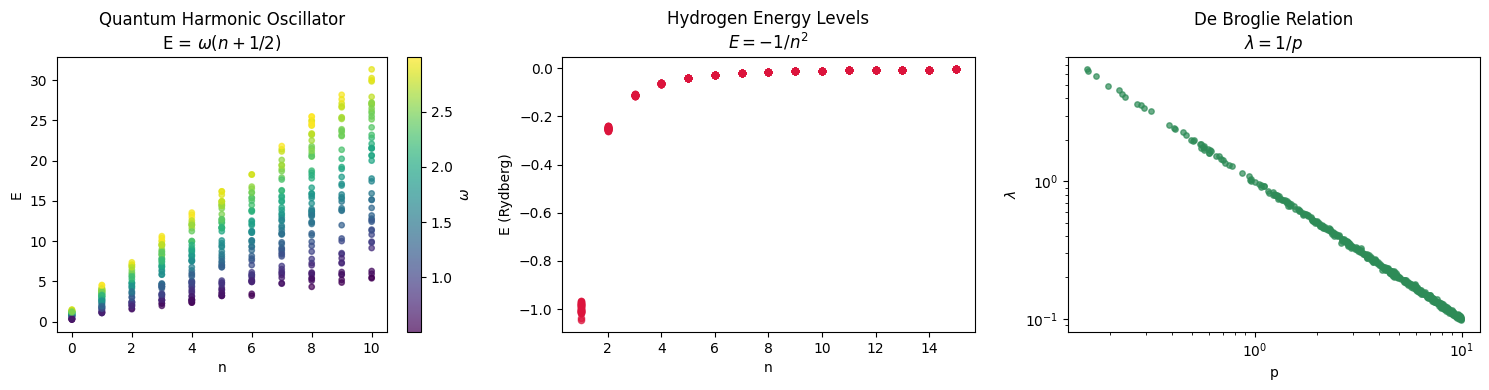

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sc0 = axes[0].scatter(X_qho[:, 0], y_qho, c=X_qho[:, 1], cmap="viridis", s=15, alpha=0.7)
axes[0].set_xlabel("n")
axes[0].set_ylabel("E")
axes[0].set_title("Quantum Harmonic Oscillator\nE = $\\omega(n + 1/2)$")
plt.colorbar(sc0, ax=axes[0], label=r"$\omega$")

axes[1].scatter(X_hyd[:, 0], y_hyd, s=20, alpha=0.7, color="crimson")
axes[1].set_xlabel("n")
axes[1].set_ylabel("E (Rydberg)")
axes[1].set_title("Hydrogen Energy Levels\n$E = -1/n^2$")

axes[2].scatter(X_deb[:, 0], y_deb, s=15, alpha=0.7, color="seagreen")
axes[2].set_xlabel("p")
axes[2].set_ylabel(r"$\lambda$")
axes[2].set_title("De Broglie Relation\n$\\lambda = 1/p$")
axes[2].set_xscale("log")
axes[2].set_yscale("log")

plt.tight_layout()
plt.savefig("../figures/data_visualization.png", dpi=120, bbox_inches="tight")
plt.show()

In [15]:
class EQLLayer(tf.keras.layers.Layer):
    """One block of the EQL network. Applies a linear projection to its input,
    then splits the projection across symbolic primitives and concatenates
    the results. Sparsity is enforced via an L1 penalty on the projection
    weights, accumulated externally via `self.W`."""
    def __init__(self, n_identity=4, n_sin=2, n_exp=2, n_inv=2, n_mul=2, **kwargs):
        super().__init__(**kwargs)
        self.n_identity=n_identity
        self.n_sin=n_sin
        self.n_exp=n_exp
        self.n_inv=n_inv
        self.n_mul=n_mul
    def build(self, input_shape):
        in_dim=input_shape[-1]
        # total slots = unary primitives + 2 * binary primitives
        self.n_unary = self.n_identity + self.n_sin + self.n_exp + self.n_inv
        self.n_slots = self.n_unary + 2 * self.n_mul
        self.W=self.add_weight(
            name="W",
            shape=(in_dim, self.n_slots),
            initializer=tf.keras.initializers.GlorotNormal(seed=SEED),
            trainable=True,
        )
        self.b = self.add_weight(
            name="b",
            shape=(self.n_slots,),
            initializer="zeros",
            trainable=True,
        )
    def call(self, x):
        z = tf.matmul(x, self.W) + self.b
        outputs = []
        idx = 0
        # identity
        if self.n_identity > 0:
            outputs.append(z[:, idx:idx + self.n_identity])
            idx += self.n_identity
        # sin
        if self.n_sin > 0:
            outputs.append(tf.sin(z[:, idx:idx + self.n_sin]))
            idx += self.n_sin
        # exp (clipped to avoid overflow / NaN)
        if self.n_exp > 0:
            clipped = tf.clip_by_value(z[:, idx:idx + self.n_exp], -10.0, 10.0)
            outputs.append(tf.exp(clipped))
            idx += self.n_exp
        # inverse (clipped denominator to avoid div-by-zero)
        if self.n_inv > 0:
            denom = z[:, idx:idx + self.n_inv]
            denom_safe = tf.where(
                tf.abs(denom) < 1e-3,
                tf.sign(denom + 1e-12) * 1e-3,
                denom,
                )
            outputs.append(1.0 / denom_safe)
            idx += self.n_inv
        # multiplication (pairs)
        if self.n_mul > 0:
            a = z[:, idx:idx + self.n_mul]
            b = z[:, idx + self.n_mul:idx + 2 * self.n_mul]
            outputs.append(a * b)
            idx += 2 * self.n_mul
        return tf.concat(outputs, axis=-1)
    def l1_penalty(self):
        """Sum of |W| — added to the loss to encourage sparse symbolic forms."""
        return tf.reduce_sum(tf.abs(self.W))
    def get_config(self):
        config = super().get_config()
        config.update({
            "n_identity": self.n_identity,
            "n_sin": self.n_sin,
            "n_exp": self.n_exp,
            "n_inv": self.n_inv,
            "n_mul": self.n_mul,
        })
        return config
print("EQLLayer defined.")           

EQLLayer defined.


In [16]:
test_layer = EQLLayer(n_identity=3, n_sin=2, n_exp=2, n_inv=2, n_mul=2)
test_input = tf.random.normal((8, 4))   # batch of 8, 4 input features
test_output = test_layer(test_input)

print("Input shape :", test_input.shape)
print("Output shape:", test_output.shape)
print()
print("Expected output dim = 3 (id) + 2 (sin) + 2 (exp) + 2 (inv) + 2 (mul) = 11")
print("Number of trainable weights:", sum([tf.size(w).numpy() for w in test_layer.trainable_weights]))
print("L1 penalty value:", test_layer.l1_penalty().numpy())

Input shape : (8, 4)
Output shape: (8, 11)

Expected output dim = 3 (id) + 2 (sin) + 2 (exp) + 2 (inv) + 2 (mul) = 11
Number of trainable weights: 65
L1 penalty value: 14.095552


In [17]:
class EQLModel(tf.keras.Model):
    """EQL network: stacked EQLLayer blocks followed by a linear output layer.
    The output layer is a Dense(1) that takes a sparse linear combination of
    the symbolic primitives produced by the last EQL block."""

    def __init__(self, input_dim, n_layers=2, layer_kwargs=None, **kwargs):
        super().__init__(**kwargs)
        layer_kwargs = layer_kwargs or {}
        self.eql_layers = [EQLLayer(**layer_kwargs) for _ in range(n_layers)]
        self.output_layer = tf.keras.layers.Dense(
            1,
            use_bias=True,
            kernel_initializer=tf.keras.initializers.GlorotNormal(seed=SEED),
        )
        self.input_dim = input_dim

    def call(self, x):
        for layer in self.eql_layers:
            x = layer(x)
        return self.output_layer(x)

    def l1_penalty(self):
        total = tf.add_n([layer.l1_penalty() for layer in self.eql_layers])
        total += tf.reduce_sum(tf.abs(self.output_layer.kernel))
        return total


def build_eql_model(input_dim, n_layers=2, n_identity=4, n_sin=2,
                    n_exp=2, n_inv=2, n_mul=2):
    """Convenience factory. Builds and initializes the model so weights
    are allocated and ready to inspect."""
    layer_kwargs = dict(
        n_identity=n_identity, n_sin=n_sin,
        n_exp=n_exp, n_inv=n_inv, n_mul=n_mul,
    )
    model = EQLModel(input_dim=input_dim, n_layers=n_layers, layer_kwargs=layer_kwargs)
    _ = model(tf.zeros((1, input_dim)))   # forces weight allocation
    return model


print("EQLModel and build_eql_model defined.")

EQLModel and build_eql_model defined.


In [18]:
print("=== QHO model (input_dim=2) ===")
m_qho = build_eql_model(input_dim=2, n_layers=2)
print("Output for batch of 16:", m_qho(tf.random.normal((16, 2))).shape)
print("Total params:", m_qho.count_params())
print("L1 penalty:", m_qho.l1_penalty().numpy())
print()

print("=== Hydrogen model (input_dim=1) ===")
m_hyd = build_eql_model(input_dim=1, n_layers=2)
print("Output for batch of 16:", m_hyd(tf.random.normal((16, 1))).shape)
print("Total params:", m_hyd.count_params())
print("L1 penalty:", m_hyd.l1_penalty().numpy())
print()

print("=== De Broglie model (input_dim=1) ===")
m_deb = build_eql_model(input_dim=1, n_layers=2)
print("Output for batch of 16:", m_deb(tf.random.normal((16, 1))).shape)
print("Total params:", m_deb.count_params())
print("L1 penalty:", m_deb.l1_penalty().numpy())

=== QHO model (input_dim=2) ===
Output for batch of 16: (16, 1)
Total params: 237
L1 penalty: 48.42913

=== Hydrogen model (input_dim=1) ===
Output for batch of 16: (16, 1)
Total params: 223
L1 penalty: 43.692738

=== De Broglie model (input_dim=1) ===
Output for batch of 16: (16, 1)
Total params: 223
L1 penalty: 43.692738


In [19]:
def train_val_split(X, y, val_frac=0.2, seed=SEED):
    """Random train/val split. Returns X_train, y_train, X_val, y_val."""
    rng = np.random.default_rng(seed)
    n = len(y)
    idx = rng.permutation(n)
    n_val = int(n * val_frac)
    val_idx, train_idx = idx[:n_val], idx[n_val:]
    return X[train_idx], y[train_idx], X[val_idx], y[val_idx]


def normalize_y(y_train, y_val, log_scale=False):
    """Z-score normalize y. If log_scale, applies log(|y|+eps) first —
    useful for targets spanning many orders of magnitude (de Broglie).
    Returns (y_train_norm, y_val_norm, stats_dict)."""
    y_tr = y_train.astype(np.float32).copy()
    y_va = y_val.astype(np.float32).copy()
    if log_scale:
        y_tr = np.log(np.abs(y_tr) + 1e-8)
        y_va = np.log(np.abs(y_va) + 1e-8)
    mean = float(y_tr.mean())
    std = float(y_tr.std()) + 1e-8
    return (y_tr - mean) / std, (y_va - mean) / std, {"mean": mean, "std": std, "log_scale": log_scale}


def denormalize_y(y_pred_norm, stats):
    """Invert normalize_y. Returns predictions in original units."""
    y = y_pred_norm * stats["std"] + stats["mean"]
    if stats["log_scale"]:
        y = np.exp(y)
    return y


print("Data prep utilities defined: train_val_split, normalize_y, denormalize_y.")

Data prep utilities defined: train_val_split, normalize_y, denormalize_y.


In [20]:
def train_eql(model, X_train, y_train, X_val, y_val,
              epochs=2000, batch_size=64, lr=1e-2,
              l1_lambda=1e-3, loss_type="huber",
              patience=200, clipnorm=1.0, verbose=200):
    """Custom training loop for an EQL model.

    Total loss = data_loss(y, preds) + l1_lambda * model.l1_penalty()

    - loss_type: 'huber' (default, robust to outliers) or 'mse'
    - clipnorm: gradient norm clipping in Adam, prevents NaN blow-ups
    - patience: early stop after this many epochs without val improvement
    - verbose: print every N epochs (set 0 to silence)

    Returns: history dict with loss curves and best epoch."""

    optimizer = tf.keras.optimizers.Adam(learning_rate=lr, clipnorm=clipnorm)

    if loss_type == "huber":
        data_loss_fn = tf.keras.losses.Huber(delta=1.0)
    elif loss_type == "mse":
        data_loss_fn = tf.keras.losses.MeanSquaredError()
    else:
        raise ValueError(f"unknown loss_type {loss_type}")

    X_train_t = tf.convert_to_tensor(X_train, dtype=tf.float32)
    y_train_t = tf.convert_to_tensor(y_train, dtype=tf.float32)
    X_val_t   = tf.convert_to_tensor(X_val,   dtype=tf.float32)
    y_val_t   = tf.convert_to_tensor(y_val,   dtype=tf.float32)

    n_train = len(y_train)
    history = {"train_loss": [], "val_loss": [], "l1": []}
    best_val, best_epoch, best_weights = np.inf, 0, None
    epochs_no_improve = 0

    @tf.function
    def train_step(xb, yb):
        with tf.GradientTape() as tape:
            preds = tf.squeeze(model(xb), axis=-1)
            data_loss = data_loss_fn(yb, preds)
            l1 = model.l1_penalty()
            total = data_loss + l1_lambda * l1
        grads = tape.gradient(total, model.trainable_weights)
        optimizer.apply_gradients(zip(grads, model.trainable_weights))
        return data_loss, l1

    for epoch in range(epochs):
        perm = tf.random.shuffle(tf.range(n_train))
        X_shuf = tf.gather(X_train_t, perm)
        y_shuf = tf.gather(y_train_t, perm)

        batch_losses = []
        for i in range(0, n_train, batch_size):
            xb = X_shuf[i:i + batch_size]
            yb = y_shuf[i:i + batch_size]
            dl, l1 = train_step(xb, yb)
            batch_losses.append(float(dl))

        val_preds = tf.squeeze(model(X_val_t), axis=-1)
        val_loss = float(data_loss_fn(y_val_t, val_preds))
        train_loss = float(np.mean(batch_losses))

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["l1"].append(float(l1))

        if val_loss < best_val - 1e-6:
            best_val, best_epoch = val_loss, epoch
            best_weights = [w.numpy().copy() for w in model.trainable_weights]
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if verbose and (epoch % verbose == 0 or epoch == epochs - 1):
            print(f"  epoch {epoch:4d}  train={train_loss:.5f}  val={val_loss:.5f}  L1={float(l1):.3f}")

        if epochs_no_improve >= patience:
            if verbose:
                print(f"  early stop at epoch {epoch} (best val={best_val:.5f} at epoch {best_epoch})")
            break

    if best_weights is not None:
        for w, bw in zip(model.trainable_weights, best_weights):
            w.assign(bw)

    history["best_val"] = best_val
    history["best_epoch"] = best_epoch
    return history


print("train_eql defined.")

train_eql defined.


In [21]:
# --- QHO: prepare data ---
X_qho_tr, y_qho_tr, X_qho_va, y_qho_va = train_val_split(X_qho, y_qho, val_frac=0.2)
y_qho_tr_n, y_qho_va_n, qho_stats = normalize_y(y_qho_tr, y_qho_va, log_scale=False)

print(f"QHO train: {X_qho_tr.shape}, val: {X_qho_va.shape}")
print(f"y_train mean={qho_stats['mean']:.3f}, std={qho_stats['std']:.3f}")

# --- build model ---
np.random.seed(SEED); tf.random.set_seed(SEED)
model_qho = build_eql_model(input_dim=2, n_layers=2)
print(f"Built QHO model with {model_qho.count_params()} params.")

# --- train ---
print("\nTraining QHO EQL...")
history_qho = train_eql(
    model_qho, X_qho_tr, y_qho_tr_n, X_qho_va, y_qho_va_n,
    epochs=2000, batch_size=64, lr=1e-2,
    l1_lambda=1e-3, loss_type="huber",
    patience=200, clipnorm=1.0, verbose=200,
)

# --- evaluate ---
def r2_score(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1.0 - ss_res / (ss_tot + 1e-12)

pred_tr_n = tf.squeeze(model_qho(X_qho_tr), axis=-1).numpy()
pred_va_n = tf.squeeze(model_qho(X_qho_va), axis=-1).numpy()
pred_tr = denormalize_y(pred_tr_n, qho_stats)
pred_va = denormalize_y(pred_va_n, qho_stats)

r2_tr = r2_score(y_qho_tr, pred_tr)
r2_va = r2_score(y_qho_va, pred_va)

print(f"\nQHO train R²: {r2_tr:.5f}")
print(f"QHO val   R²: {r2_va:.5f}")
print(f"Best val (normalized): {history_qho['best_val']:.5f} at epoch {history_qho['best_epoch']}")

QHO train: (400, 2), val: (100, 2)
y_train mean=9.736, std=7.199
Built QHO model with 237 params.

Training QHO EQL...
  epoch    0  train=2.01775  val=1.04550  L1=47.275
  epoch  200  train=0.00094  val=0.00090  L1=8.138
  epoch  400  train=0.00176  val=0.00243  L1=4.197
  early stop at epoch 540 (best val=0.00045 at epoch 340)

QHO train R²: 0.99891
QHO val   R²: 0.99914
Best val (normalized): 0.00045 at epoch 340


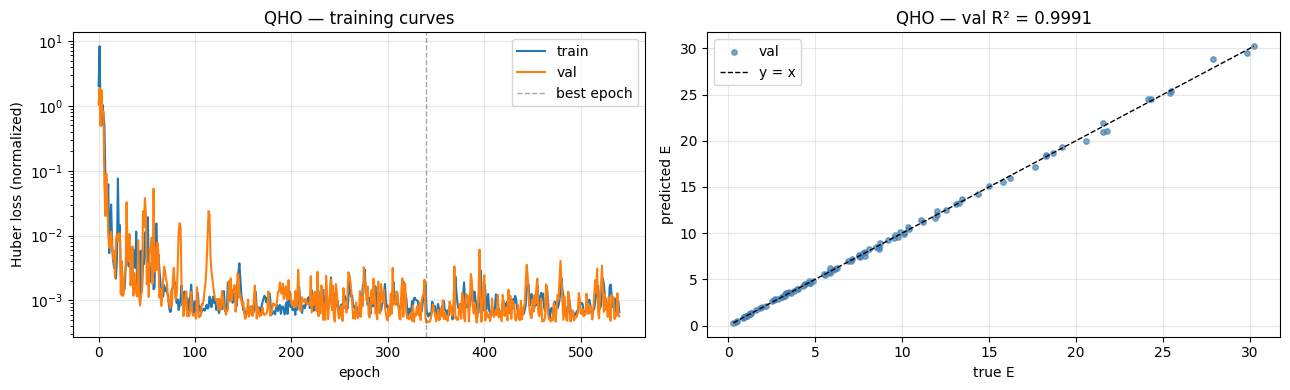

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Loss curves (Huber loss in normalized units)
axes[0].plot(history_qho["train_loss"], label="train", lw=1.5)
axes[0].plot(history_qho["val_loss"], label="val", lw=1.5)
axes[0].axvline(history_qho["best_epoch"], color="gray", ls="--", lw=1, alpha=0.7, label="best epoch")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("Huber loss (normalized)")
axes[0].set_yscale("log")
axes[0].set_title("QHO — training curves")
axes[0].legend()
axes[0].grid(alpha=0.3)

# True vs predicted
axes[1].scatter(y_qho_va, pred_va, s=15, alpha=0.7, color="steelblue", label="val")
lims = [min(y_qho_va.min(), pred_va.min()), max(y_qho_va.max(), pred_va.max())]
axes[1].plot(lims, lims, "k--", lw=1, label="y = x")
axes[1].set_xlabel("true E")
axes[1].set_ylabel("predicted E")
axes[1].set_title(f"QHO — val R² = {r2_va:.4f}")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../figures/qho_training.png", dpi=120, bbox_inches="tight")
plt.show()